# Modeling Logistic Growth: part 2

We will re-elaborate the results obtained in the previous parts, by performing additional experiments in order to gain more insights on the model and how UDE behaves with it.

In [1]:
# modules
from torch import nn
import torch 
import pysindy as ps
from sr3_modified import my_SR3 as SR3
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt 
from torchdiffeq import odeint
from scipy.integrate import quad
import matplotlib as mpl 
from typing import Tuple 
from numpy.typing import NDArray
from scipy.optimize import fsolve


In [2]:
# define the model same as before
k = 6
rho0 = 1
rho = np.array(
    [0, 0.25, 0.1, 0.001, 1]
)

def generalised_growth(t, data, k, rho):
    x = data[0]
    powers = np.arange(1, k)
    x_pow = np.power(x, powers)

    return np.array(
        [rho0 * x * (1 - np.dot(x_pow, rho)) ]
    )


In [3]:
# helper function for polynomial definition

def poly_sindy(x, deg: int, model: ps.SINDy):
    # evaluates a polynomial of degree deg with trained SINDy model's coefficient
    p = np.zeros(deg)
    p[1:] = model.coefficients()

    p = p[::-1]

    return np.polyval(p, x)

def poly_real(x, deg):
    p = np.zeros(deg)

    p[1] = 1

    p[2:] = -rho0 * rho.reshape(deg-2)

    p = p[::-1]

    return np.polyval(p, x)


## Step 0: extremal cases

We will see the cases where we choose extremal initial points for the UDE to simulate, that is $x_0 = 0.01$ and $x_0 = 2$

### $x_0 = 0.01$

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]


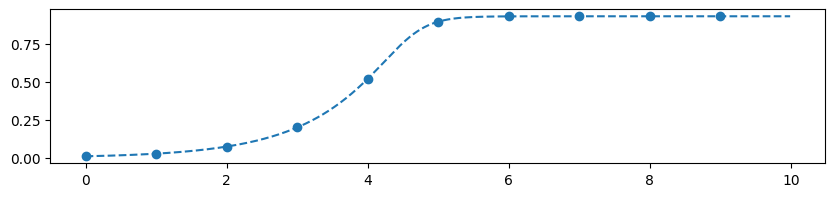

In [7]:
T_MAX = 10.

x0 = 0.01

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]


fig, axes = plt.subplots(figsize=(10, 2))

plt.plot(T, X, "--", label="True X")


T_train = T[::100]
X_train = X[::100]

print(T_train)
plt.scatter(T_train, X_train, label="Training Data X")


plt.show()

In [40]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=5000, verbose=True)
)
model_old.fit(X_train, T_train, feature_names=['x'])

model_old.print()

 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.2849e-02 ... 0.0000e+00 ... 3.0000e-02 ... 6.2849e-02
         1 ... 1.9868e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.9868e-02
         2 ... 1.8072e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.8072e-02
         3 ... 1.6788e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.6788e-02
         4 ... 1.5854e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.5854e-02
         5 ... 1.5174e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.5174e-02
         6 ... 1.4679e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4679e-02
         7 ... 1.4318e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4318e-02
         8 ... 1.4054e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.4054e-02
         9 ... 1.3861e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3861e-02
        10 ... 1.3720e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3720e-02
        11 ... 1.3615e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.3615e-02
        12 ... 1.3537e-02 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


In [41]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [42]:
my_growth = ude_generalised_growth(rho0)

lr = 0.005
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)

n_epochs = 1000

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch,
                    t_train_torch,
                    rtol=1e-7, atol=1e-7,
                    method='rk4' # RK4 for faster performances
                    )
    
    # Compute loss at training points

    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        print(f"{EPOCH}\t{loss.item()}")




0	0.42562246322631836
1	0.38060182332992554
2	0.28933924436569214
3	0.1623697131872177
4	0.2938298285007477
5	0.18117356300354004
6	0.13757391273975372
7	0.15400533378124237
8	0.1724725067615509
9	0.1766168773174286
10	0.16692796349525452
11	0.14776644110679626
12	0.12534640729427338
13	0.10621944814920425
14	0.09380429983139038
15	0.08638037741184235
16	0.07944779098033905
17	0.06978169828653336
18	0.05709170177578926
19	0.043036963790655136
20	0.02966916933655739
21	0.018502917140722275
22	0.01025962270796299
23	0.004982967860996723
24	0.0022805584594607353
25	0.0015566172078251839
26	0.0021803616546094418
27	0.003586075734347105
28	0.005321573931723833
29	0.0070616090670228004
30	0.00859846267849207
31	0.009820087812840939
32	0.010684517212212086
33	0.011196175590157509
34	0.011386655271053314
35	0.011300344951450825
36	0.010984501801431179
37	0.010483252815902233
38	0.009834833443164825
39	0.009071378037333488
40	0.008220672607421875
41	0.007308638654649258
42	0.00636189803481102
4

In [139]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude_xsmall.dinomeng")

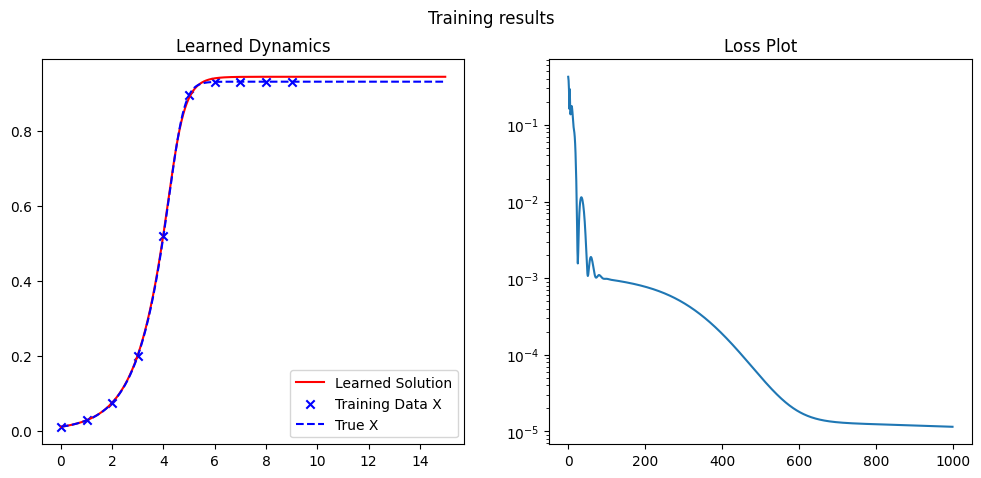

In [43]:
T_MAX = 15
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pred = odeint(my_growth, 
                x0_torch,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func = axes[0]

func.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func.scatter(T_train, X_train, label="Training Data X", color='blue', marker='x')
func.plot(T, X, "--", label="True X", color='blue')
func.legend()
func.set_title("Learned Dynamics")

loss = axes[1]

loss.semilogy(losses)
loss.set_title("Loss Plot")

plt.suptitle("Training results")

plt.show()

In [44]:
X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=50000, verbose=True)
)

model.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())


c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(
c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.1576e-02 ... 0.0000e+00 ... 3.0000e-02 ... 6.1576e-02
         1 ... 1.5645e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.5645e-02
         2 ... 1.1448e-02 ... 0.0000e+00 ... 3.0000e-02 ... 4.1448e-02
         3 ... 8.4219e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.8422e-02
         4 ... 6.2250e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.6225e-02
         5 ... 4.6301e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.4630e-02
         6 ... 3.4724e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.3472e-02
         7 ... 2.6318e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.2632e-02
         8 ... 2.0216e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.2022e-02
         9 ... 1.5785e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1579e-02
        10 ... 1.2568e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1257e-02
        11 ... 1.0232e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.1023e-02
        12 ... 8.5352e-04 ... 0.0000e+00 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 3.7352e-02 ... 0.0000e+00 ... 3.0000e-02 ... 6.7352e-02
         1 ... 8.6559e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.8656e-02
         2 ... 5.6429e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5643e-02
         3 ... 5.3074e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5307e-02
         4 ... 5.2576e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5258e-02
         5 ... 5.2387e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5239e-02
         6 ... 5.2233e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5223e-02
         7 ... 5.2085e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5209e-02
         8 ... 5.1939e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5194e-02
         9 ... 5.1795e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5180e-02
        10 ... 5.1652e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5165e-02
        11 ... 5.1511e-03 ... 0.0000e+00 ... 3.0000e-02 ... 3.5151e-02
        12 ... 5.1370e-03 ... 0.0000e+00 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


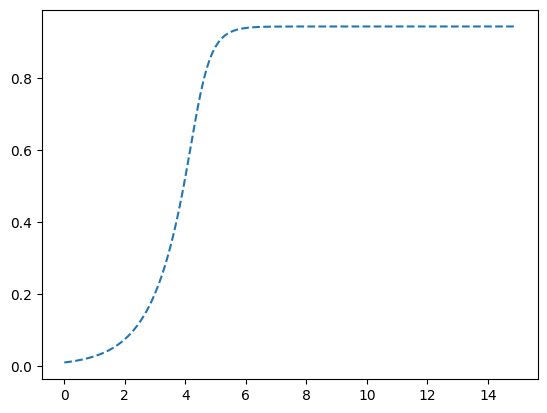

In [45]:
# Now... train SINDy with the new derivatives

# recover data
bigger_t_train = torch.arange(0, T_MAX, 0.1)


sol = odeint(my_growth, 
                    torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                    bigger_t_train,
                    )

data = sol.detach().numpy()

T = bigger_t_train.detach().numpy()
X = data

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T, X)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))


model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True),
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy())

In [46]:
model.print()
model_lots.print()

(x)' =  1.034 x + -1.118 x^4 + -0.127 x^5
(x)' =  1.021 x + -0.962 x^4 + -0.269 x^5


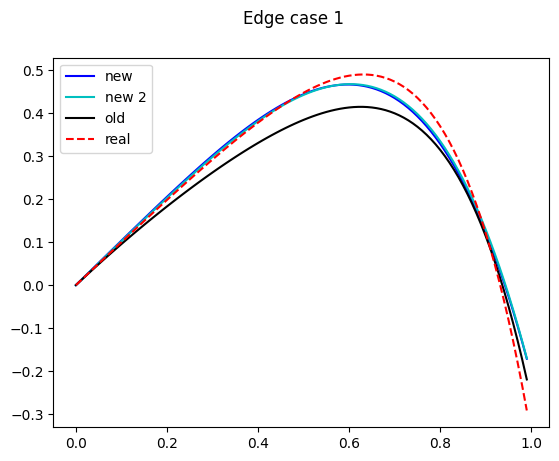

In [47]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="new")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="new 2")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="old")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="real")

plt.suptitle("Edge case 1")

plt.legend()

plt.show()



In [48]:
def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

def poly_diff3(x):
    return (poly_sindy(x, k+1, model_lots)-poly_real(x, k+1))**2

print("L2 Eror in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1)[0],"\nL2 Error after:\t",
quad(poly_diff1, 0, 1)[0],"\nL2 Error after (with more data):\t", quad(poly_diff3, 0,1)[0])

L2 Eror in [0,1] before data augmentation with UDEs:	 0.002318303812376467 
L2 Error after:	 0.0009017216541727898 
L2 Error after (with more data):	 0.0008391175275594991


### x_0 = 2

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]


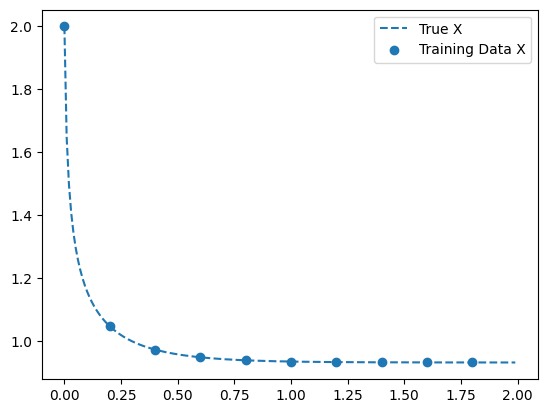

In [49]:
T_MAX = 2

x0 = 2

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", label="True X")


T_train = T[::20]
X_train = X[::20]


print(T_train)
plt.scatter(T_train, X_train, label="Training Data X")


plt.legend()

plt.show()

In [50]:
model_old = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=5000, verbose=True)
)
model_old.fit(X_train, T_train, feature_names=['x'])

model_old.print()

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\utils\_axes.py:126: AxesWarning: 2 axes labeled for array with 1 axes
  warnings.warn(


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 4.2461e+00 ... 0.0000e+00 ... 3.0000e-02 ... 4.2761e+00
         1 ... 3.9271e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.9571e+00
         2 ... 3.6518e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.6818e+00
         3 ... 3.3973e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.4273e+00
         4 ... 3.1620e+00 ... 0.0000e+00 ... 3.0000e-02 ... 3.1920e+00
         5 ... 2.9445e+00 ... 9.5101e-03 ... 3.0000e-02 ... 2.9840e+00
         6 ... 2.7356e+00 ... 2.6915e-04 ... 3.0000e-02 ... 2.7659e+00
         7 ... 2.5515e+00 ... 1.9222e-03 ... 3.0000e-02 ... 2.5834e+00
         8 ... 2.3834e+00 ... 2.5778e-03 ... 3.0000e-02 ... 2.4160e+00
         9 ... 2.2283e+00 ... 2.6525e-03 ... 3.0000e-02 ... 2.2610e+00
        10 ... 2.0849e+00 ... 2.5395e-03 ... 3.0000e-02 ... 2.1175e+00
        11 ... 1.9521e+00 ... 2.3789e-03 ... 3.0000e-02 ... 1.9845e+00
        12 ... 1.8292e+00 ... 2.2134e-03 ... 3.

c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 5000 iterations.
  warnings.warn(


In [51]:
# Step 2. Create UDE of type x NN(x) and make it learn...

class ude_generalised_growth(nn.Module):
    def __init__(self, rho0):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 10),
            nn.Tanh(),
            nn.Linear(10, 1)
        ) 

    def forward(self, t, x):
        return x * (self.net(x))

In [53]:
my_growth = ude_generalised_growth(rho0)

lr = 0.005
optimizer = torch.optim.Adam(my_growth.parameters(), lr=lr)
rtol = 1e-7

n_epochs = 1000

t_train_torch = torch.tensor(T_train, dtype=torch.float32)
x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

losses = []

for EPOCH in (range(n_epochs)):
    optimizer.zero_grad()
    
    # forward solution
    x_pred = odeint(my_growth, 
                    x0_torch,
                    t_train_torch,
                    rtol=1e-9, atol=1e-9,
                    method='rk4'
                    )
    
    # Compute loss at training points

    loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
    
    # Backpropagate
    loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        losses.append(loss.detach())
        print(f"{EPOCH}\t{loss.item()}")




0	0.40330663323402405
1	0.2182072401046753
2	0.1380079686641693
3	0.10997519642114639
4	0.10652760416269302
5	0.11253732442855835
6	0.12025002390146255
7	0.12624147534370422
8	0.1293637603521347
9	0.1295222043991089
10	0.12706415355205536
11	0.12251806259155273
12	0.11650143563747406
13	0.10970158874988556
14	0.10287656635046005
15	0.0968368873000145
16	0.09236239641904831
17	0.08999539911746979
18	0.08968152105808258
19	0.09043850004673004
20	0.09059742838144302
21	0.08882973343133926
22	0.08498798310756683
23	0.07992339879274368
24	0.07472790777683258
25	0.07014572620391846
26	0.06639397144317627
27	0.06327477842569351
28	0.060395002365112305
29	0.057371728122234344
30	0.053969450294971466
31	0.050161052495241165
32	0.04612201824784279
33	0.04216637462377548
34	0.03863111138343811
35	0.03572970628738403
36	0.03343391790986061
37	0.03147655352950096
38	0.029518157243728638
39	0.027367686852812767
40	0.02507500909268856
41	0.022848190739750862
42	0.02089928463101387
43	0.01933122240006

In [24]:
torch.save(my_growth.state_dict(), "./models_weights/growth_ude_xbig.dinomeng")

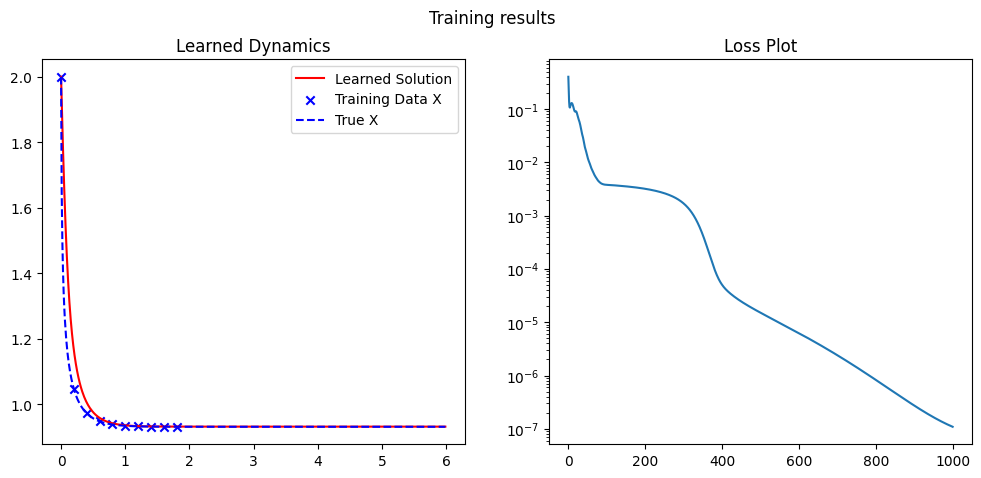

In [54]:
T_MAX = 6
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x_pred = odeint(my_growth, 
                x0_torch,
                T_torch := torch.arange(0, T_MAX, 0.01)
                )

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))

T = sol.t
X = sol.y[0]

func = axes[0]

func.plot(T_torch, x_pred.detach().numpy(), label="Learned Solution", color='red')
func.scatter(T_train, X_train, label="Training Data X", color='blue', marker='x')
func.plot(T, X, "--", label="True X", color='blue')
func.legend()
func.set_title("Learned Dynamics")

loss = axes[1]

loss.semilogy(losses)
loss.set_title("Loss Plot")

plt.suptitle("Training results")

plt.show()

In [55]:
X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T_train, X_train)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True)
)

model.fit(X_train.reshape(-1, 1), T_train, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 1.4923e-01 ... 2.1062e-03 ... 3.0000e-02 ... 1.8134e-01
         1 ... 1.2870e-01 ... 4.4681e-03 ... 3.0000e-02 ... 1.6317e-01
         2 ... 1.2191e-01 ... 6.0641e-03 ... 3.0000e-02 ... 1.5797e-01
         3 ... 1.1607e-01 ... 7.4158e-03 ... 3.0000e-02 ... 1.5348e-01
         4 ... 1.1093e-01 ... 8.5263e-03 ... 3.0000e-02 ... 1.4946e-01
         5 ... 1.0636e-01 ... 9.4020e-03 ... 3.0000e-02 ... 1.4576e-01
         6 ... 1.0225e-01 ... 0.0000e+00 ... 3.0000e-02 ... 1.3225e-01
         7 ... 9.4500e-02 ... 0.0000e+00 ... 3.0000e-02 ... 1.2450e-01
         8 ... 8.7364e-02 ... 0.0000e+00 ... 3.0000e-02 ... 1.1736e-01
         9 ... 8.0767e-02 ... 0.0000e+00 ... 3.0000e-02 ... 1.1077e-01
        10 ... 7.4668e-02 ... 0.0000e+00 ... 3.0000e-02 ... 1.0467e-01
        11 ... 6.9030e-02 ... 0.0000e+00 ... 3.0000e-02 ... 9.9030e-02
        12 ... 6.3817e-02 ... 0.0000e+00 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


 Iteration ... |y - Xw|^2 ...  |w-u|^2/v ...       R(u) ... Total Error: |y-Xw|^2 + |w-u|^2/v + R(u)
         0 ... 7.0103e-01 ... 9.8777e-03 ... 3.0000e-02 ... 7.4091e-01
         1 ... 9.3697e-02 ... 1.6629e-03 ... 3.0000e-02 ... 1.2536e-01
         2 ... 2.2324e-02 ... 1.2334e-03 ... 3.0000e-02 ... 5.3557e-02
         3 ... 1.2604e-02 ... 3.0850e-04 ... 3.0000e-02 ... 4.2913e-02
         4 ... 1.1095e-02 ... 4.3700e-05 ... 3.0000e-02 ... 4.1138e-02
         5 ... 1.0813e-02 ... 1.3551e-06 ... 3.0000e-02 ... 4.0814e-02
         6 ... 1.0734e-02 ... 1.7508e-06 ... 3.0000e-02 ... 4.0736e-02
         7 ... 1.0692e-02 ... 5.8274e-06 ... 3.0000e-02 ... 4.0698e-02
         8 ... 1.0658e-02 ... 8.3032e-06 ... 3.0000e-02 ... 4.0667e-02
         9 ... 1.0626e-02 ... 9.4760e-06 ... 3.0000e-02 ... 4.0636e-02
        10 ... 1.0595e-02 ... 9.9802e-06 ... 3.0000e-02 ... 4.0605e-02
        11 ... 1.0564e-02 ... 1.0181e-05 ... 3.0000e-02 ... 4.0574e-02
        12 ... 1.0533e-02 ... 1.0249e-05 ... 3.

,optimizer,my_SR3(initia... verbose=True)
,feature_library,PolynomialLib...de_bias=False)
,differentiation_method,FiniteDifference(axis=-2)
,degree,6
,include_interaction,True
,interaction_only,False
,include_bias,False
,order,'C'
,reg_weight_lam,0.005
,regularizer,'L0'
,relax_coeff_nu,1.0


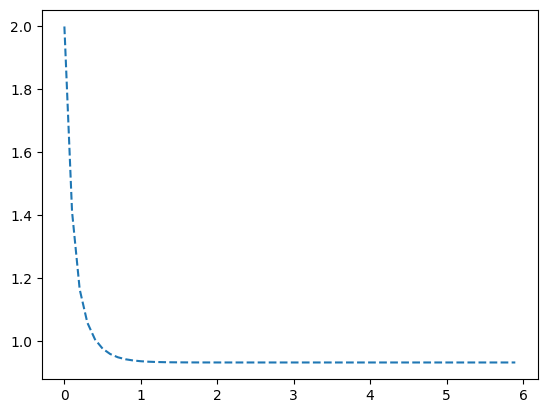

In [56]:
# Now... train SINDy with the new derivatives

# recover data
bigger_t_train = torch.arange(0, T_MAX, 0.1)


sol = odeint(my_growth, 
                    torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                    bigger_t_train,
                    )

data = sol.detach().numpy()

T = bigger_t_train.detach().numpy()
X = data

plt.plot(T, X, "--", label="True X")


# we use lots of data instead
T_train = T
X_train = X

X_dot = torch.zeros(T_train.shape[0])

for i, (t, x) in enumerate(zip(T, X)):
    X_dot[i] = my_growth(t, torch.tensor([x], dtype=torch.float32))

model_lots = ps.SINDy(
    feature_library=ps.PolynomialLibrary(k, include_bias=False),
    optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=True),
)

model_lots.fit(X_train, T_train, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))

In [57]:
model.print()
model_lots.print()

(x)' =  1.888 x + -0.850 x^3 + -1.214 x^4 + -0.811 x^5 +  0.633 x^6
(x)' =  2.334 x + -2.472 x^3 + -0.662 x^5 +  0.444 x^6


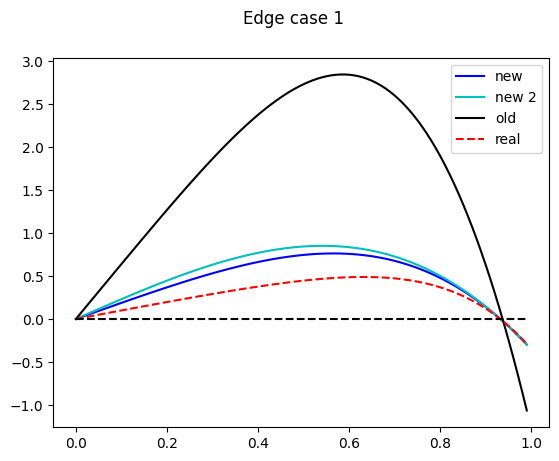

L2 Erorr in [0,1] before data augmentation with UDEs:	 (2.60279739636364, 2.889685597877323e-14) 
L2 Error after:	 (0.03941311093604641, 4.3757343233304277e-16) 
L2 Error after (with more data):	 (0.0713090110452891, 7.916890592572956e-16)


In [58]:
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model), "b", label="new")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_lots), "c", label="new 2")
plt.plot(np.arange(0, 1, 0.01), poly_sindy(np.arange(0, 1, 0.01), k+1, model_old), "k", label="old")
plt.plot(np.arange(0, 1, 0.01), poly_real(np.arange(0, 1, 0.01), k+1), "r--", label="real")

plt.plot(np.arange(0, 1, 0.01), np.zeros_like(np.arange(0, 1, 0.01)), "k--")

plt.suptitle("Edge case 1")

plt.legend()

plt.show()

def poly_diff1(x):
    return (poly_sindy(x, k+1, model)-poly_real(x, k+1))**2

def poly_diff2(x):
    return (poly_sindy(x, k+1, model_old)-poly_real(x, k+1))**2

def poly_diff3(x):
    return (poly_sindy(x, k+1, model_lots)-poly_real(x, k+1))**2

print("L2 Erorr in [0,1] before data augmentation with UDEs:\t", quad(poly_diff2, 0, 1),"\nL2 Error after:\t",
quad(poly_diff1, 0, 1),"\nL2 Error after (with more data):\t", quad(poly_diff3, 0,1))

### Variation of the initial state $x_0 \in [0.01, 2]$
Let's generalize the previous code, being particularly careful of choosing T_MAX for each initial state as convergence times can vary

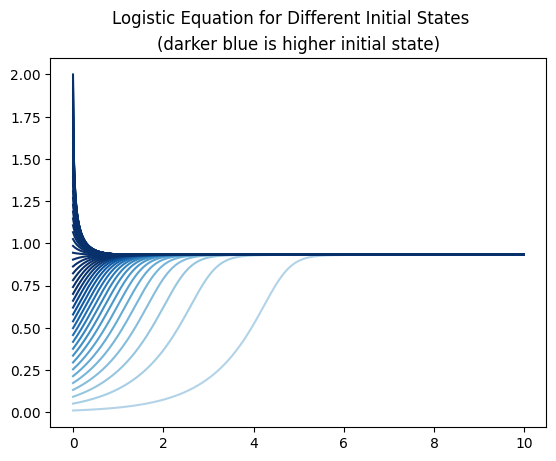

In [11]:
x0_space = np.linspace(0.01, 2, 50)


cmap = mpl.colormaps["Blues"]

colors = cmap(x0_space + 0.3)

T_MAX = 10.


for i, x0 in enumerate(x0_space):
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    plt.plot(T, X, color=colors[i])

plt.suptitle("Logistic Equation for Different Initial States")
plt.title("(darker blue is higher initial state)")
plt.show()

One smart idea might be to take "relevant" time series, that is the portion of the simulation that leads to the time state (to avoid redundant data in training)

In [12]:
# calculate the steady state as the non-zero root of the polynomial term:

steady_state = fsolve(lambda x: poly_real(x, k+1), 1)
print(steady_state)

[0.93154041]


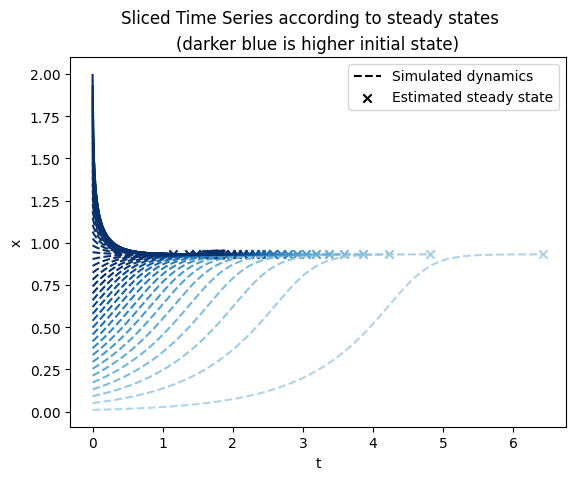

In [14]:
for i, x0 in enumerate(x0_space):
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-8, atol=1e-8, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    mask = np.where(np.abs(X-steady_state) <= 1e-4)
    X_steady = X[mask[0][0]]
    T_steady = T[mask[0][0]]

    mask_time = np.where(T <= T_steady)
    X_sliced = X[mask_time]
    T_sliced = T[mask_time]

    plt.plot(T_sliced, X_sliced, color=colors[i], linestyle='--')
    plt.scatter(T_steady, steady_state, color=colors[i], marker='x')

plt.xlabel("t")

plt.ylabel("x")

plt.plot([], [], 'k--', label='Simulated dynamics')
plt.scatter([], [], color='k', marker='x', label='Estimated steady state')
plt.legend()

plt.suptitle("Sliced Time Series according to steady states")
plt.title("(darker blue is higher initial state)")
plt.show()

Implement the full pipeline


In [116]:
def get_training_data(x0: int) -> Tuple[NDArray, NDArray]:
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-8, atol=1e-8, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    mask = np.where(np.abs(X-steady_state) <= 1e-4)
    T_steady = T[mask[0][0]]

    mask_time = np.where(T <= T_steady+4)
    X_sliced = X[mask_time]
    T_sliced = T[mask_time]

    divider = len(X_sliced) // 10
    X_train = X_sliced[::divider+1]
    T_train = T_sliced[::divider+1]

    return (X_train, T_train)


In [117]:

def train_model(x0: int, model: ude_generalised_growth, X_train: NDArray, T_train: NDArray) -> float:
    lr = 0.005
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    n_epochs = 2500

    t_train_torch = torch.tensor(T_train, dtype=torch.float32)
    x0_torch = torch.tensor([x0], dtype=torch.float32, requires_grad=True)
    x_train_torch = torch.tensor(X_train, dtype=torch.float32).view(-1, 1)

    for EPOCH in (range(n_epochs)):
        optimizer.zero_grad()
        
        # forward solution
        x_pred = odeint(model, 
                        x0_torch,
                        t_train_torch,
                        rtol=1e-7, atol=1e-7,
                        method='rk4'
                        )
        
        # Compute loss at training points

        loss = torch.mean(torch.pow(x_pred-x_train_torch, 2))
        
        # Backpropagate
        loss.backward()
        optimizer.step()
        
    return loss.item() # return the last loss


In [ ]:
def train_sindy_models(x0, X_train: NDArray, T_train: NDArray, model: ude_generalised_growth) -> Tuple[ps.SINDy, ps.SINDy, ps.SINDy]:

    # baseline: numerically approximated derivates and origianl data
    baseline_model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=10000, verbose=False)
    )
    baseline_model.fit(X_train.reshape(-1, 1), T_train, feature_names=['x'])

    X_dot = torch.zeros(T_train.shape[0])

    for i, (t, x) in enumerate(zip(T_train, X_train)):
        X_dot[i] = model(t, torch.tensor([x], dtype=torch.float32))

    # ude1: UDE-enhanced approach, original data
    ude_model = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=False)
    )

    ude_model.fit(X_train.reshape(-1, 1), T_train, feature_names=['x'], x_dot=X_dot.detach().numpy().reshape(-1, 1))

    # ude2: UDE-enhanced approach, more data!
    # recover data
    T_extended = torch.arange(0, np.max(T_train)+1, 0.05)


    sol = odeint(model, 
                        torch.tensor([x0], dtype=torch.float32, requires_grad=True),
                        T_extended,
                        )

    data_new = sol.detach().numpy()

    T_extended_np = T_extended.detach().numpy().reshape(-1, 1)
    X_new = data_new.reshape(-1, 1)

    X_dot_new = torch.zeros(T_extended_np.shape[0])

    # train sindy model
    for i, (t, x) in enumerate(zip(T_extended_np, X_new)):
        X_dot_new[i] = model(t, torch.tensor([x], dtype=torch.float32))


    ude_model_augmented = ps.SINDy(
        feature_library=ps.PolynomialLibrary(k, include_bias=False),
        optimizer=SR3(initial_guess=np.array([1, 0, 0, 0, 0, 0]).reshape(1,6), max_iter=100000, verbose=False),
    )
    ude_model_augmented.fit(X_new, T_extended_np, feature_names=['x'], x_dot=X_dot_new.detach().numpy().reshape(-1, 1))

    return (baseline_model, ude_model, ude_model_augmented)

In [119]:
def results_sindy_models(baseline: ps.SINDy, ude1: ps.SINDy, ude2: ps.SINDy):
    # calculate L2 losses for each sindy model with respect to the real polynomial
    return {
        'baseline': quad(lambda x: ((poly_sindy(x, k+1, baseline)-poly_real(x, k+1))**2), 0, 1 )[0],
        'ude_enhanced': quad(lambda x: ((poly_sindy(x, k+1, ude1)-poly_real(x, k+1))**2), 0, 1 )[0],
        'ude_enhanced_augmented': quad(lambda x: ((poly_sindy(x, k+1, ude2)-poly_real(x, k+1))**2), 0, 1 )[0],
    }

In [ ]:
x0_space = np.linspace(0.01, 2, 50)

loss_models = []

l2_baseline = []
l2_ude = []
l2_superude = []

for x0 in tqdm(x0_space):
    X_train, T_train = get_training_data(x0)
    ude_model = ude_generalised_growth(rho0)
    lass_lost = train_model(x0, ude_model, X_train, T_train)
    sindy_baseline, sindy_ude, sindy_ude_extended = train_sindy_models(x0, X_train, T_train, ude_model)

    dicts = results_sindy_models(sindy_baseline, sindy_ude, sindy_ude_extended)

    loss_models += [lass_lost]

    l2_baseline += [dicts['baseline']]
    l2_ude += [dicts['ude_enhanced']]
    l2_superude += [dicts['ude_enhanced_augmented']]
    

 22%|██▏       | 11/50 [06:51<20:54, 32.18s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 42%|████▏     | 21/50 [13:32<20:04, 41.54s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 48%|████▊     | 24/50 [15:19<16:36, 38.31s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 50%|█████     | 25/50 [15:56<15:48, 37.94s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 52%|█████▏    | 26/50 [16:30<14:40, 36.67s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-package

In [122]:
np.savetxt("sindy_logs/loss_models.txt", loss_models, delimiter="\t")
np.savetxt("sindy_logs/l2_baseline.txt", l2_baseline, delimiter="\t")
np.savetxt("sindy_logs/l2_superude.txt", l2_superude, delimiter="\t")
np.savetxt("sindy_logs/l2_ude.txt", l2_ude, delimiter="\t")


In [5]:
# load
loss_models=np.loadtxt("sindy_logs/loss_models.txt", delimiter="\t")
l2_baseline=np.loadtxt("sindy_logs/l2_baseline.txt", delimiter="\t")
l2_superude=np.loadtxt("sindy_logs/l2_superude.txt", delimiter="\t")
l2_ude=np.loadtxt("sindy_logs/l2_ude.txt", delimiter="\t")
x0_space = np.linspace(0.01, 2, 50)
steady_state = fsolve(lambda x: poly_real(x, k+1), 1)


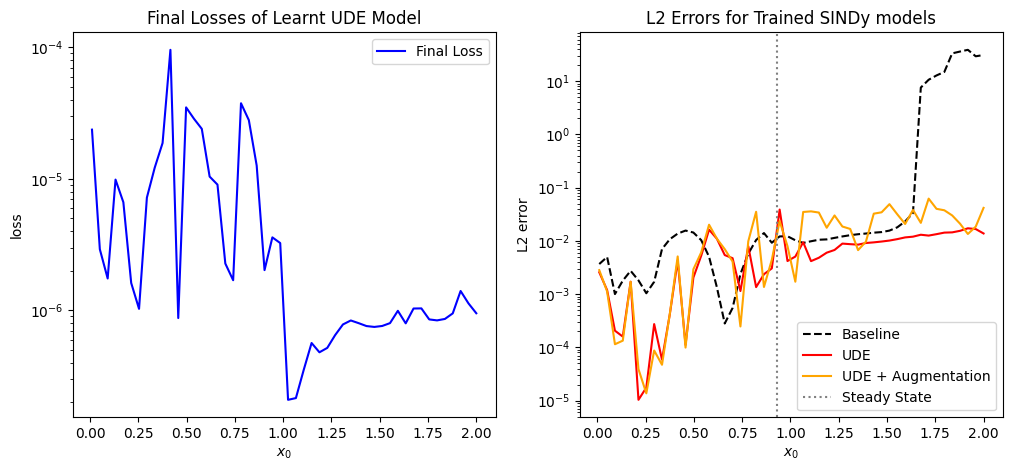

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axes[0]
ax1 = axes[1]

ax0.semilogy(x0_space, loss_models, color="blue", label="Final Loss")
ax0.set_xlabel("$x_0$")
ax0.set_ylabel("loss")
ax1.semilogy(x0_space, l2_baseline, label="Baseline", color="black", linestyle="--")
ax1.semilogy(x0_space, l2_ude, label="UDE", color="red")
ax1.semilogy(x0_space, l2_superude, label="UDE + Augmentation", color="orange")

ax1.axvline(steady_state, linestyle=":", color="grey", label="Steady State")

ax1.set_xlabel("$x_0$")
ax1.set_ylabel("L2 error")


ax1.set_title("L2 Errors for Trained SINDy models")
ax0.set_title("Final Losses of Learnt UDE Model")

ax0.legend()
ax1.legend()

plt.show()


migliorare le annotazioni grafici

l'opposto di quello che ci aspettavamo: proprio al centro si hanno i peggiori risultati

# Changing the amount of training data

Fix $x_0 = 0.5$ and let the amount of data points in the time series change. What happens?

In [94]:
def get_training_n_points(x0: int, n:int) -> Tuple[NDArray, NDArray]:
    sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-8, atol=1e-8, dense_output=True, t_eval=np.arange
                    (0,T_MAX, 0.01))
    data = sol.y

    T = sol.t
    X = data[0]

    mask = np.where(np.abs(X-steady_state) <= 1e-4)
    T_steady = T[mask[0][0]]

    mask_time = np.where(T <= T_steady+4)
    X_sliced = X[mask_time]
    T_sliced = T[mask_time]

    divider = len(X_sliced) // n
    X_train = X_sliced[::divider+1]
    T_train = T_sliced[::divider+1]

    return (X_train, T_train)


In [103]:
n = range(3, 30)
x0 = 1

loss_models = []

l2_baseline = []
l2_ude = []
l2_superude = []

for size in tqdm(n):
    X_train, T_train = get_training_n_points(x0, size)
    ude_model = ude_generalised_growth(rho0)
    lass_lost = train_model(x0, ude_model, X_train, T_train)
    sindy_baseline, sindy_ude, sindy_ude_extended = train_sindy_models(X_train, T_train, ude_model)

    dicts = results_sindy_models(sindy_baseline, sindy_ude, sindy_ude_extended)

    loss_models += [lass_lost]

    l2_baseline += [dicts['baseline']]
    l2_ude += [dicts['ude_enhanced']]
    l2_superude += [dicts['ude_enhanced_augmented']]
    

 19%|█▊        | 5/27 [01:39<08:11, 22.33s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 22%|██▏       | 6/27 [02:04<08:06, 23.15s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 26%|██▌       | 7/27 [02:31<08:12, 24.64s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 30%|██▉       | 8/27 [03:05<08:41, 27.44s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pysindy\optimizers\sr3.py:374: ConvergenceWarning: SR3 did not converge after 10000 iterations.
  warnings.warn(
 33%|███▎      | 9/27 [03:39<08:51, 29.51s/it]c:\Users\ACER\anaconda3\envs\AIDA_BSC_THESIS\Lib\site-packages\pys

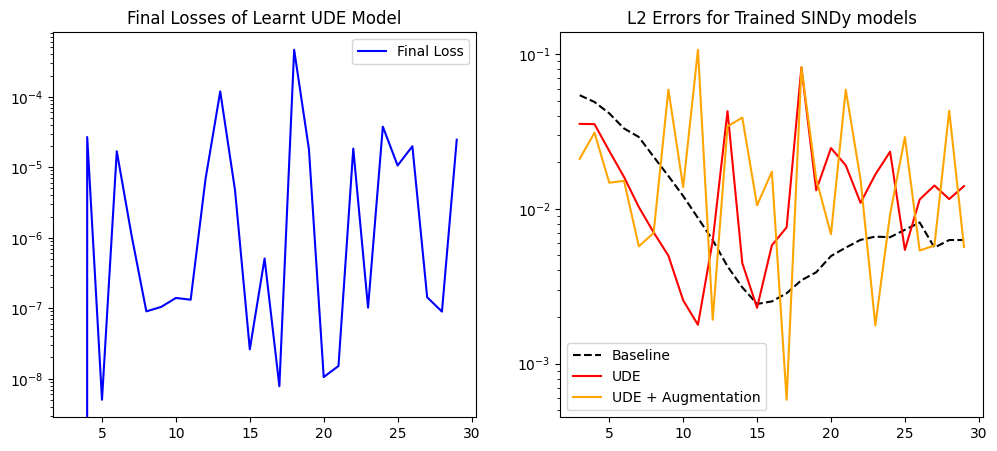

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax0 = axes[0]
ax1 = axes[1]

ax0.semilogy(n, loss_models, color="blue", label="Final Loss")
ax1.semilogy(n, l2_baseline, label="Baseline", color="black", linestyle="--")
ax1.semilogy(n, l2_ude, label="UDE", color="red")
ax1.semilogy(n, l2_superude, label="UDE + Augmentation", color="orange")

ax1.set_title("L2 Errors for Trained SINDy models")
ax0.set_title("Final Losses of Learnt UDE Model")

ax0.legend()
ax1.legend()

plt.show()


do tables

# Misc

[0.  0.2 0.4 0.6 0.8 1.  1.2 1.4 1.6 1.8]


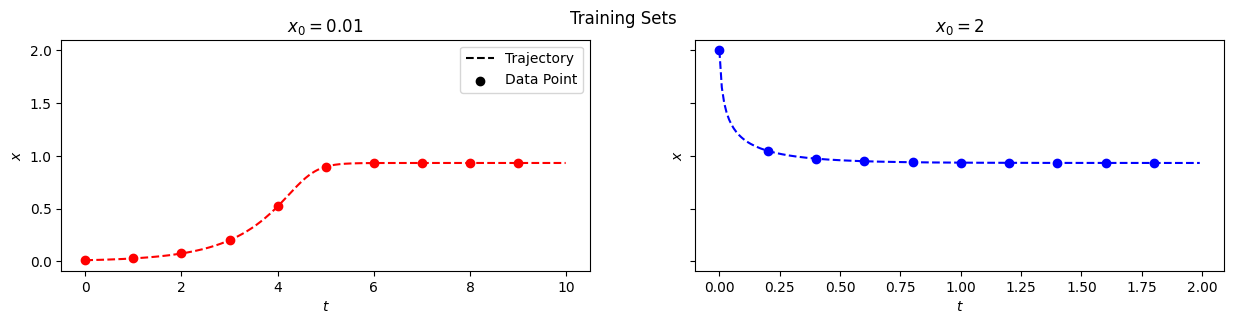

In [23]:
# print datasets, only for thesis purposes
fig, axes = plt.subplots(1, 2, figsize=(15, 3), sharey=True)
plt.sca(axes[0])

T_MAX = 10.

x0 = 0.01

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", color='red')

plt.xlabel("$t$")
plt.ylabel("$x$")

T_train = T[::100]
X_train = X[::100]


plt.scatter(T_train, X_train, color='red')
plt.plot([], [], linestyle="--", label="Trajectory", color='k')
plt.scatter([], [], marker='o', label="Data Point", color='k')
plt.legend()
plt.title("$x_0=0.01$")


plt.sca(axes[1])
T_MAX = 2

x0 = 2

sol = solve_ivp(generalised_growth, t_span = [0, T_MAX], args= (k, rho), y0 = [x0], rtol=1e-9, atol=1e-9, dense_output=True, t_eval=np.arange
                (0,T_MAX, 0.01))
data = sol.y

T = sol.t
X = data[0]

plt.plot(T, X, "--", color='blue')


T_train = T[::20]
X_train = X[::20]


print(T_train)
plt.scatter(T_train, X_train, color='blue')
plt.xlabel("$t$")
plt.ylabel("$x$")

plt.title("$x_0=2$")
plt.suptitle("Training Sets")

plt.show()